# GAN Project: DCGAN vs WGAN-GP
### Tackling Mode Collapse in Generative Adversarial Networks
---
**Platform:** Kaggle | **Accelerator:** GPU T4 x2 | **Dataset:** Pokémon Sprites + Anime Faces

## SECTION 1 — Environment Setup

### Cell 1.1 — Install Required Libraries

In [6]:
# Install extra libraries not pre-installed on Kaggle
!pip install -q clean-fid gradio torchmetrics

### Cell 1.2 — Import All Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

print('All libraries imported successfully!')

All libraries imported successfully!


### Cell 1.3 — Set Random Seeds for Reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f'Random seed set to: {SEED}')

Random seed set to: 42


### Cell 1.4 — Detect and Configure GPUs

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()

print(f'Device        : {device}')
print(f'GPUs available: {num_gpus}')

for i in range(num_gpus):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name}  |  VRAM: {props.total_memory // 1024**2} MB')

Device        : cuda
GPUs available: 2
  GPU 0: Tesla T4  |  VRAM: 14912 MB
  GPU 1: Tesla T4  |  VRAM: 14912 MB


### Cell 1.5 — Global Hyperparameters

In [15]:
# ── Image / Training config ──────────────────────────────────────────
IMAGE_SIZE   = 64
BATCH_SIZE   = 64
Z_DIM        = 100      # noise vector dimension
NUM_CHANNELS = 3
FEATURES_G   = 64       # base features for generator
FEATURES_D   = 64       # base features for discriminator/critic

# ── Optimizer config ─────────────────────────────────────────────────
LR           = 0.0002
BETA1        = 0.5
BETA2        = 0.999

# ── Training epochs ──────────────────────────────────────────────────
DCGAN_EPOCHS  = 50
WGAN_EPOCHS   = 50
SAVE_EVERY    = 5    # save checkpoint every N epochs

# ── WGAN-GP specific ─────────────────────────────────────────────────
LAMBDA_GP     = 10      # gradient penalty weight
CRITIC_STEPS  = 5       # critic updates per generator update

# ── Paths ─────────────────────────────────────────────────────────────
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Hyperparameters configured!')
print(f'  Image size : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Z dimension: {Z_DIM}')
print(f'  LR / Betas : {LR} / ({BETA1}, {BETA2})')

Hyperparameters configured!
  Image size : 64x64
  Batch size : 64
  Z dimension: 100
  LR / Betas : 0.0002 / (0.5, 0.999)


---
## SECTION 2 — Data Preparation

### Cell 2.1 — List Available Dataset Paths

In [16]:
# Kaggle automatically mounts datasets at /kaggle/input/
# Make sure both datasets are added via the dataset panel on the right

import os

# POKEMON_PATH = '/kaggle/input/pokemon-sprites'
ANIME_PATH   = '/kaggle/input/datasets/soumikrakshit/anime-faces'

for path, name in [ (ANIME_PATH, 'Anime Faces')]:
    if os.path.exists(path):
        files = sum(len(f) for _, _, f in os.walk(path))
        print(f'{name:12s} → found at {path}  ({files} files)')
    else:
        print(f'{name:12s} → NOT FOUND at {path} — please add the dataset')

# Choose which dataset to train on (change as needed)
DATA_PATH = ANIME_PATH
print(f'\nUsing dataset: {DATA_PATH}')

Anime Faces  → found at /kaggle/input/datasets/soumikrakshit/anime-faces  (43102 files)

Using dataset: /kaggle/input/datasets/soumikrakshit/anime-faces


### Cell 2.2 — Define Image Transforms

In [17]:
# All images → 64×64, normalized to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],   # maps [0,1] → [-1, 1]
        std =[0.5, 0.5, 0.5]
    )
])

print('Transform pipeline:')
print(transform)

Transform pipeline:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(64, 64))
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


### Cell 2.3 — Load Dataset

In [18]:
# ImageFolder expects: data_dir/class_name/image.png
# Both datasets are organised this way

full_dataset = ImageFolder(root=DATA_PATH, transform=transform)


Full dataset : 43102 images


### Cell 2.4 — Create DataLoader

In [19]:
dataloader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True,
    drop_last   = True    # keeps batch size consistent
)

print(f'DataLoader ready!')
print(f'  Total batches per epoch: {len(dataloader)}')
print(f'  Batch size             : {BATCH_SIZE}')

DataLoader ready!
  Total batches per epoch: 673
  Batch size             : 64


### Cell 2.5 — Visualize Sample Images from Dataset

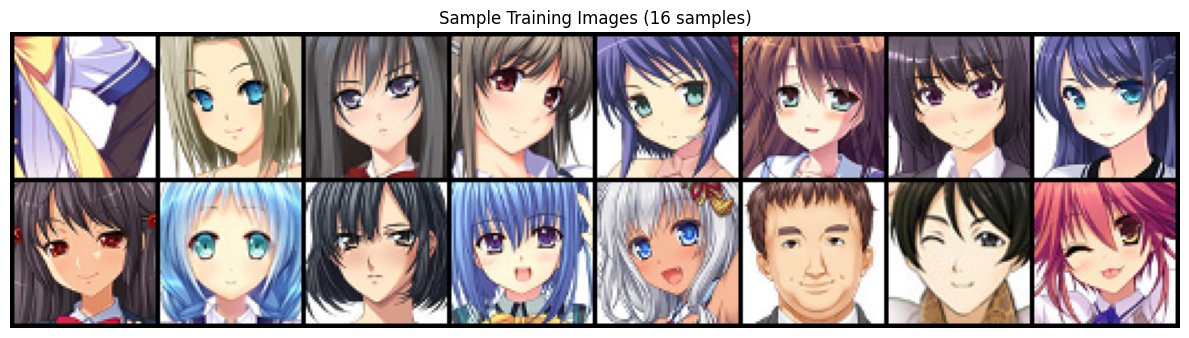

Image tensor shape: torch.Size([64, 3, 64, 64])  (B, C, H, W)


In [20]:
def denormalize(tensor):
    """Convert [-1,1] tensor back to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Grab one batch and display a grid
sample_batch, _ = next(iter(dataloader))
grid = torchvision.utils.make_grid(denormalize(sample_batch[:16]), nrow=8, padding=2)

plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title('Sample Training Images (16 samples)')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image tensor shape: {sample_batch.shape}  (B, C, H, W)')

---
## SECTION 3 — Model Architecture

### Cell 3.1 — Weight Initialization (shared by both models)

In [22]:
def weights_init(model):
    """
    Initialize conv and batchnorm weights as per the DCGAN paper:
    - Conv weights : Normal(mean=0, std=0.02)
    - BN weights   : Normal(mean=1, std=0.02)
    - BN bias      : 0
    """
    classname = model.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

print('weights_init function defined!')

weights_init function defined!


### Cell 3.2 — DCGAN Generator

In [23]:
class DCGANGenerator(nn.Module):
    """
    Input : noise vector z of shape (batch, Z_DIM, 1, 1)
    Output: RGB image of shape (batch, 3, 64, 64)
    
    Architecture: ConvTranspose2d → BatchNorm → ReLU  (×4 layers)
                  Final layer: ConvTranspose2d → Tanh
    """
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()
        fg = features_g
        self.net = nn.Sequential(
            # z: (z_dim) → 4×4
            self._block(z_dim,    fg*16, 4, 1, 0),   # → 4×4
            self._block(fg*16,    fg*8,  4, 2, 1),   # → 8×8
            self._block(fg*8,     fg*4,  4, 2, 1),   # → 16×16
            self._block(fg*4,     fg*2,  4, 2, 1),   # → 32×32
            # final layer — no BatchNorm, Tanh activation
            nn.ConvTranspose2d(fg*2, channels_img, 4, 2, 1),  # → 64×64
            nn.Tanh()
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, z):
        return self.net(z)

print('DCGANGenerator class defined!')

DCGANGenerator class defined!


### Cell 3.3 — DCGAN Discriminator

In [24]:
class DCGANDiscriminator(nn.Module):
    """
    Sigmoid removed from final layer.
    BCEWithLogitsLoss handles sigmoid internally — safe for autocast.
    """
    def __init__(self, channels_img, features_d):
        super().__init__()
        fd = features_d
        self.net = nn.Sequential(
            nn.Conv2d(channels_img, fd, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(fd,   fd*2, 4, 2, 1),
            self._block(fd*2, fd*4, 4, 2, 1),
            self._block(fd*4, fd*8, 4, 2, 1),
            # No Sigmoid here — BCEWithLogitsLoss applies it internally
            nn.Conv2d(fd*8, 1, 4, 1, 0, bias=False)
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x)

print('DCGANDiscriminator (no Sigmoid) defined!')

DCGANDiscriminator (no Sigmoid) defined!


### Cell 3.4 — Instantiate DCGAN Models

In [25]:
# Instantiate
dcgan_G = DCGANGenerator(Z_DIM, NUM_CHANNELS, FEATURES_G).to(device)
dcgan_D = DCGANDiscriminator(NUM_CHANNELS, FEATURES_D).to(device)

# Apply weight init
dcgan_G.apply(weights_init)
dcgan_D.apply(weights_init)

# Wrap in DataParallel for dual GPU
if num_gpus > 1:
    dcgan_G = nn.DataParallel(dcgan_G)
    dcgan_D = nn.DataParallel(dcgan_D)
    print('DataParallel enabled for dual GPU!')

# Count parameters
g_params = sum(p.numel() for p in dcgan_G.parameters())
d_params = sum(p.numel() for p in dcgan_D.parameters())
print(f'DCGAN Generator params    : {g_params:,}')
print(f'DCGAN Discriminator params: {d_params:,}')

DataParallel enabled for dual GPU!
DCGAN Generator params    : 12,658,435
DCGAN Discriminator params: 2,765,568


### Cell 3.5 — WGAN-GP Critic

In [26]:
class WGANCritic(nn.Module):
    """
    Same architecture as DCGAN Discriminator BUT:
    - NO Sigmoid at the end  (outputs raw real-valued score)
    - NO BatchNorm (use InstanceNorm or no norm for WGAN-GP)
    """
    def __init__(self, channels_img, features_d):
        super().__init__()
        fd = features_d
        self.net = nn.Sequential(
            nn.Conv2d(channels_img, fd, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(fd,   fd*2, 4, 2, 1),
            self._block(fd*2, fd*4, 4, 2, 1),
            self._block(fd*4, fd*8, 4, 2, 1),
            # No Sigmoid — raw score output
            nn.Conv2d(fd*8, 1, 4, 1, 0, bias=False)
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.InstanceNorm2d(out_c, affine=True),  # InstanceNorm instead of BatchNorm
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x)

print('WGANCritic class defined!')

WGANCritic class defined!


### Cell 3.6 — WGAN-GP Generator (reused from DCGAN)

In [27]:
# ── WGAN-GP Models ───────────────────────────────────────────────────
wgan_G = DCGANGenerator(Z_DIM, NUM_CHANNELS, FEATURES_G).to(device)
wgan_C = WGANCritic(NUM_CHANNELS, FEATURES_D).to(device)

wgan_G.apply(weights_init)
wgan_C.apply(weights_init)

if num_gpus > 1:
    wgan_G = nn.DataParallel(wgan_G)
    wgan_C = nn.DataParallel(wgan_C)

# ── WGAN-GP Optimizers ───────────────────────────────────────────────
opt_wgan_G = optim.Adam(wgan_G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_wgan_C = optim.Adam(wgan_C.parameters(), lr=LR, betas=(BETA1, BETA2))

# ── Mixed Precision Scalers ──────────────────────────────────────────
scaler_wgan_G = GradScaler()
scaler_wgan_C = GradScaler()

print('WGAN-GP models and optimizers ready!')
g_params = sum(p.numel() for p in wgan_G.parameters())
c_params = sum(p.numel() for p in wgan_C.parameters())
print(f'  Generator params : {g_params:,}')
print(f'  Critic params    : {c_params:,}')

WGAN-GP models and optimizers ready!
  Generator params : 12,658,435
  Critic params    : 2,765,568


/tmp/ipykernel_55/1086780932.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_wgan_G = GradScaler()
/tmp/ipykernel_55/1086780932.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_wgan_C = GradScaler()


---
## SECTION 4 — Loss Functions & Optimizers

### Cell 4.1 — DCGAN Loss (Binary Cross Entropy)

In [28]:
# BCEWithLogitsLoss = Sigmoid + BCE fused together
# This is numerically stable AND safe with autocast / mixed precision
criterion_bce = nn.BCEWithLogitsLoss()

# Label smoothing
REAL_LABEL = 0.9
FAKE_LABEL = 0.0

print('BCEWithLogitsLoss defined (autocast-safe)!')
print(f'  Real label: {REAL_LABEL}')
print(f'  Fake label: {FAKE_LABEL}')

BCEWithLogitsLoss defined (autocast-safe)!
  Real label: 0.9
  Fake label: 0.0


### Cell 4.2 — WGAN-GP: Gradient Penalty Function

In [29]:
def compute_gradient_penalty(critic, real, fake, device):
    """
    Gradient Penalty for WGAN-GP.
    
    Steps:
    1. Sample random interpolation factor epsilon.
    2. Create interpolated image between real and fake.
    3. Pass interpolated image through critic.
    4. Compute gradient of critic output w.r.t. interpolated image.
    5. Penalize deviation of gradient norm from 1.
    """
    batch_size, C, H, W = real.shape

    # Step 1: random epsilon for interpolation
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device).expand_as(real)

    # Step 2: interpolated images
    interpolated = (epsilon * real + (1 - epsilon) * fake).requires_grad_(True)

    # Step 3: critic score on interpolated images
    critic_interp = critic(interpolated)

    # Step 4: compute gradients
    gradients = torch.autograd.grad(
        outputs   = critic_interp,
        inputs    = interpolated,
        grad_outputs = torch.ones_like(critic_interp),
        create_graph = True,
        retain_graph = True
    )[0]

    # Step 5: gradient penalty = (||grad|| - 1)^2
    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    penalty   = ((grad_norm - 1) ** 2).mean()
    return penalty

print('compute_gradient_penalty() defined!')

compute_gradient_penalty() defined!


### Cell 4.3 — Define Optimizers for Both Models

In [30]:
# Must re-instantiate after changing Discriminator architecture
dcgan_G = DCGANGenerator(Z_DIM, NUM_CHANNELS, FEATURES_G).to(device)
dcgan_D = DCGANDiscriminator(NUM_CHANNELS, FEATURES_D).to(device)

dcgan_G.apply(weights_init)
dcgan_D.apply(weights_init)

if num_gpus > 1:
    dcgan_G = nn.DataParallel(dcgan_G)
    dcgan_D = nn.DataParallel(dcgan_D)

opt_dcgan_G = optim.Adam(dcgan_G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_dcgan_D = optim.Adam(dcgan_D.parameters(), lr=LR, betas=(BETA1, BETA2))

scaler_dcgan_G = GradScaler()
scaler_dcgan_D = GradScaler()

print('DCGAN models, optimizers and scalers re-initialized!')

DCGAN models, optimizers and scalers re-initialized!


/tmp/ipykernel_55/2802356615.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_dcgan_G = GradScaler()
/tmp/ipykernel_55/2802356615.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_dcgan_D = GradScaler()


### Cell 4.4 — Fixed Noise for Consistent Visualization

In [31]:
# Fixed noise vector — used throughout training to track progress
FIXED_NOISE = torch.randn(16, Z_DIM, 1, 1, device=device)

print(f'Fixed noise shape: {FIXED_NOISE.shape}')
print('This noise vector is reused every epoch to track image quality over time.')

Fixed noise shape: torch.Size([16, 100, 1, 1])
This noise vector is reused every epoch to track image quality over time.


---
## SECTION 5 — Helper Utilities

### Cell 5.1 — Checkpoint Save/Load Functions

In [32]:
def save_checkpoint(epoch, model, optimizer, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save({
        'epoch'     : epoch,
        'model'     : model.state_dict(),
        'optimizer' : optimizer.state_dict()
    }, path)
    print(f'  Checkpoint saved: {path}')

def load_checkpoint(model, optimizer, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    print(f'  Loaded checkpoint: {path}  (epoch {ckpt["epoch"]})')
    return ckpt['epoch']

print('save_checkpoint / load_checkpoint defined!')

save_checkpoint / load_checkpoint defined!


### Cell 5.2 — Image Display Utility

In [33]:
def show_generated_images(generator, noise, title='Generated Images', nrow=8):
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(noise).cpu()
    generator.train()

    grid = torchvision.utils.make_grid(denormalize(fake_imgs), nrow=nrow, padding=2)
    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_loss_curves(g_losses, d_losses, title='Training Loss'):
    plt.figure(figsize=(10, 4))
    plt.plot(g_losses, label='Generator Loss',     color='royalblue')
    plt.plot(d_losses, label='Discriminator/Critic Loss', color='tomato')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print('show_generated_images / show_loss_curves defined!')

show_generated_images / show_loss_curves defined!


### Cell 5.3 — GPU Memory Monitor

In [34]:
def print_gpu_memory():
    for i in range(torch.cuda.device_count()):
        alloc   = torch.cuda.memory_allocated(i)   / 1024**2
        reserved= torch.cuda.memory_reserved(i)    / 1024**2
        print(f'  GPU {i}: Allocated={alloc:.1f} MB  |  Reserved={reserved:.1f} MB')

print_gpu_memory()

  GPU 0: Allocated=117.7 MB  |  Reserved=178.0 MB
  GPU 1: Allocated=0.0 MB  |  Reserved=0.0 MB


---
## SECTION 6 — DCGAN Training

### Cell 6.1 — DCGAN: Single Batch Forward Pass (Discriminator)

In [35]:
def dcgan_train_discriminator(real_imgs):
    dcgan_D.zero_grad()
    batch_size = real_imgs.size(0)
    real_imgs  = real_imgs.to(device)

    # Real images — target 0.9 (label smoothing)
    real_labels = torch.full((batch_size,), REAL_LABEL, device=device)

    with torch.amp.autocast('cuda'):
        real_output = dcgan_D(real_imgs).view(-1)
        loss_real   = criterion_bce(real_output, real_labels)

    scaler_dcgan_D.scale(loss_real).backward()

    # Fake images — target 0.0
    noise       = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
    fake_labels = torch.full((batch_size,), FAKE_LABEL, device=device)

    with torch.amp.autocast('cuda'):
        fake_imgs   = dcgan_G(noise).detach()
        fake_output = dcgan_D(fake_imgs).view(-1)
        loss_fake   = criterion_bce(fake_output, fake_labels)

    scaler_dcgan_D.scale(loss_fake).backward()
    scaler_dcgan_D.step(opt_dcgan_D)
    scaler_dcgan_D.update()

    return (loss_real + loss_fake).item()

print('dcgan_train_discriminator() fixed!')

dcgan_train_discriminator() fixed!


### Cell 6.2 — DCGAN: Single Batch Forward Pass (Generator)

In [36]:
def dcgan_train_generator(batch_size):
    dcgan_G.zero_grad()

    noise       = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
    # Use real labels — generator wants discriminator to think fakes are real
    real_labels = torch.full((batch_size,), REAL_LABEL, device=device)

    with torch.amp.autocast('cuda'):
        fake_imgs = dcgan_G(noise)
        d_output  = dcgan_D(fake_imgs).view(-1)
        loss_G    = criterion_bce(d_output, real_labels)

    scaler_dcgan_G.scale(loss_G).backward()
    scaler_dcgan_G.step(opt_dcgan_G)
    scaler_dcgan_G.update()

    return loss_G.item()

print('dcgan_train_generator() fixed!')

dcgan_train_generator() fixed!


### Cell 6.3 — DCGAN: Full Training Loop

In [40]:
# Choose which checkpoint to resume from
RESUME_EPOCH = 40   # change to 20 if you want to start from epoch 20

# Load Generator
load_checkpoint(dcgan_G, opt_dcgan_G, f'dcgan_G_epoch{RESUME_EPOCH}.pth')

# Load Discriminator
load_checkpoint(dcgan_D, opt_dcgan_D, f'dcgan_D_epoch{RESUME_EPOCH}.pth')

print(f'\nResumed successfully from Epoch {RESUME_EPOCH}!')
print(f'Training will continue from Epoch {RESUME_EPOCH + 1} to {DCGAN_EPOCHS}')

  Loaded checkpoint: /kaggle/working/checkpoints/dcgan_G_epoch40.pth  (epoch 40)
  Loaded checkpoint: /kaggle/working/checkpoints/dcgan_D_epoch40.pth  (epoch 40)

Resumed successfully from Epoch 40!
Training will continue from Epoch 41 to 50


Continuing existing loss history (15 epochs recorded)
Resuming DCGAN Training...


Epoch [ 41/50]  G_loss: 3.4673  D_loss: 0.5161


Epoch [ 42/50]  G_loss: 3.6391  D_loss: 0.4376


Epoch [ 43/50]  G_loss: 3.5034  D_loss: 0.5300


Epoch [ 44/50]  G_loss: 3.7315  D_loss: 0.4202


...

Epoch [ 46/50]  G_loss: 3.7973  D_loss: 0.4224


Epoch [ 47/50]  G_loss: 3.6684  D_loss: 0.4892


Epoch [ 48/50]  G_loss: 3.6337  D_loss: 0.5054


Epoch [ 49/50]  G_loss: 3.8109  D_loss: 0.4172


Epoch [ 50/50]  G_loss: 3.3095  D_loss: 0.6618


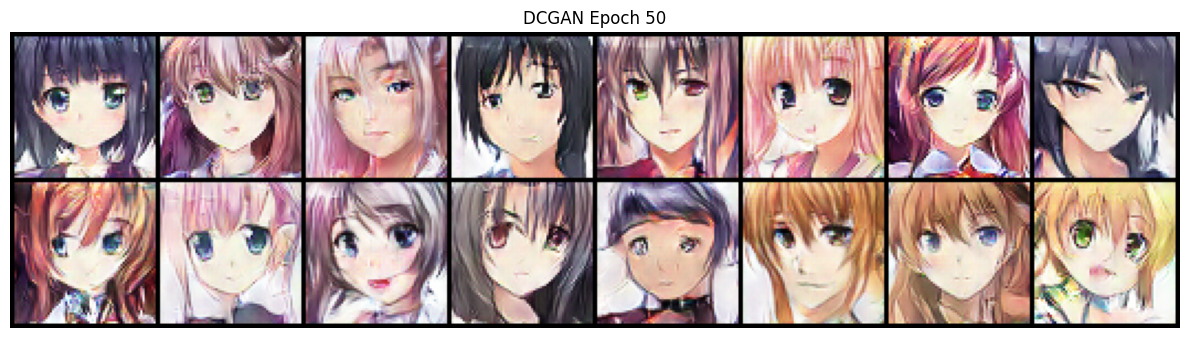

  Checkpoint saved: /kaggle/working/checkpoints/dcgan_G_epoch50.pth
  Checkpoint saved: /kaggle/working/checkpoints/dcgan_D_epoch50.pth
DCGAN Training Complete!


In [41]:
# Keep existing loss history if lists already exist, else start fresh

try:
    dcgan_G_losses
    dcgan_D_losses
    print(f'Continuing existing loss history ({len(dcgan_G_losses)} epochs recorded)')
except NameError:
    dcgan_G_losses = []
    dcgan_D_losses = []
    print('Starting fresh loss history')
print('Resuming DCGAN Training...')
print('=' * 60)
dcgan_G.train()
dcgan_D.train()
# ← START_EPOCH is RESUME_EPOCH + 1, not 1
START_EPOCH = RESUME_EPOCH + 1
for epoch in range(START_EPOCH, DCGAN_EPOCHS + 1):
    batch_g_losses = []
    batch_d_losses = []
    for batch_idx, (real_imgs, _) in enumerate(tqdm(dataloader, desc=f'Epoch [{epoch:3d}/{DCGAN_EPOCHS}]', leave=False)):
        d_loss = dcgan_train_discriminator(real_imgs)
        g_loss = dcgan_train_generator(real_imgs.size(0))
        batch_g_losses.append(g_loss)
        batch_d_losses.append(d_loss)
    avg_g = np.mean(batch_g_losses)
    avg_d = np.mean(batch_d_losses)
    dcgan_G_losses.append(avg_g)
    dcgan_D_losses.append(avg_d)
    print(f'Epoch [{epoch:3d}/{DCGAN_EPOCHS}]  G_loss: {avg_g:.4f}  D_loss: {avg_d:.4f}')
    if epoch % 10 == 0:
        show_generated_images(dcgan_G, FIXED_NOISE, title=f'DCGAN Epoch {epoch}')
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(epoch, dcgan_G, opt_dcgan_G, f'dcgan_G_epoch{epoch}.pth')
        save_checkpoint(epoch, dcgan_D, opt_dcgan_D, f'dcgan_D_epoch{epoch}.pth')
print('=' * 60)
print('DCGAN Training Complete!')

### Cell 6.4 — DCGAN: Loss Curves After Training

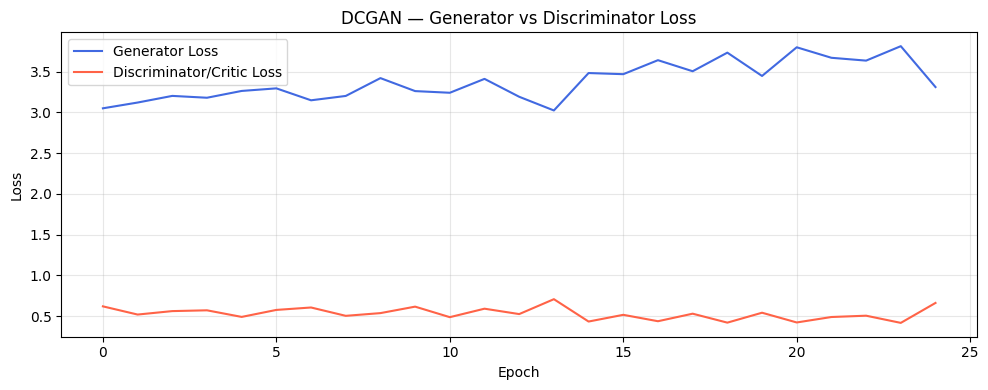

In [42]:
show_loss_curves(dcgan_G_losses, dcgan_D_losses, title='DCGAN — Generator vs Discriminator Loss')

---
## SECTION 7 — WGAN-GP Training

### Cell 7.1 — WGAN-GP: Single Batch Critic Update

In [37]:
def wgan_train_critic(real_imgs):
    """
    Train the critic for one batch.
    Wasserstein loss = E[D(fake)] - E[D(real)] + lambda * GradientPenalty
    Returns: critic loss (scalar)
    """
    wgan_C.zero_grad()
    batch_size = real_imgs.size(0)
    real_imgs  = real_imgs.to(device)

    # Generate fake images
    noise     = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
    fake_imgs = wgan_G(noise).detach()

    # Critic scores
    score_real = wgan_C(real_imgs).mean()
    score_fake = wgan_C(fake_imgs).mean()

    # Gradient penalty
    gp = compute_gradient_penalty(wgan_C, real_imgs, fake_imgs, device)

    # Wasserstein loss (maximize real - fake → minimize fake - real)
    loss_C = score_fake - score_real + LAMBDA_GP * gp

    loss_C.backward()
    opt_wgan_C.step()

    return loss_C.item()

print('wgan_train_critic() defined!')

wgan_train_critic() defined!


### Cell 7.2 — WGAN-GP: Single Batch Generator Update

In [38]:
def wgan_train_generator(batch_size):
    """
    Train generator for one batch.
    Goal: maximize E[C(G(z))] → minimize -E[C(G(z))]
    Returns: generator loss (scalar)
    """
    wgan_G.zero_grad()

    noise     = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
    fake_imgs = wgan_G(noise)
    loss_G    = -wgan_C(fake_imgs).mean()  # maximize critic score = minimize negative

    loss_G.backward()
    opt_wgan_G.step()

    return loss_G.item()

print('wgan_train_generator() defined!')

wgan_train_generator() defined!


### Cell 7.3 — WGAN-GP: Full Training Loop

In [ ]:
wgan_G_losses = []
wgan_C_losses = []
print('Starting WGAN-GP Training...')
print('=' * 60)
wgan_G.train()
wgan_C.train()
for epoch in range(1, WGAN_EPOCHS + 1):
    batch_g_losses = []
    batch_c_losses = []
    for batch_idx, (real_imgs, _) in enumerate(tqdm(dataloader, desc=f'Epoch [{epoch:3d}/{WGAN_EPOCHS}]', leave=False)):
        # Step 1: Train critic CRITIC_STEPS times per generator step
        for _ in range(CRITIC_STEPS):
            c_loss = wgan_train_critic(real_imgs)
        batch_c_losses.append(c_loss)
        # Step 2: Train generator once
        g_loss = wgan_train_generator(real_imgs.size(0))
        batch_g_losses.append(g_loss)
    avg_g = np.mean(batch_g_losses)
    avg_c = np.mean(batch_c_losses)
    wgan_G_losses.append(avg_g)
    wgan_C_losses.append(avg_c)
    print(f'Epoch [{epoch:3d}/{WGAN_EPOCHS}]  G_loss: {avg_g:.4f}  C_loss: {avg_c:.4f}')
    if epoch % 10 == 0:
        show_generated_images(wgan_G, FIXED_NOISE, title=f'WGAN-GP Epoch {epoch}')
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(epoch, wgan_G, opt_wgan_G, f'wgan_G_epoch{epoch}.pth')
        save_checkpoint(epoch, wgan_C, opt_wgan_C, f'wgan_C_epoch{epoch}.pth')
print('=' * 60)
print('WGAN-GP Training Complete!')

### Cell 7.4 — WGAN-GP: Loss Curves After Training

In [ ]:
show_loss_curves(wgan_G_losses, wgan_C_losses, title='WGAN-GP — Generator vs Critic Loss')

---
## SECTION 8 — Evaluation & Comparison

### Cell 8.1 — Generate Final Images from Both Models

In [ ]:
# Generate 10 images from each model using the same noise
eval_noise = torch.randn(10, Z_DIM, 1, 1, device=device)

dcgan_G.eval()
wgan_G.eval()

with torch.no_grad():
    dcgan_samples = denormalize(dcgan_G(eval_noise)).cpu()
    wgan_samples  = denormalize(wgan_G(eval_noise)).cpu()

print(f'DCGAN  samples shape: {dcgan_samples.shape}')
print(f'WGAN-GP samples shape: {wgan_samples.shape}')

### Cell 8.2 — Side-by-Side Comparison Grid

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('DCGAN (top) vs WGAN-GP (bottom) — Same Noise Input', fontsize=14, y=1.02)

for i in range(10):
    # DCGAN row
    axes[0, i].imshow(dcgan_samples[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('DCGAN', fontsize=10, loc='left')

    # WGAN-GP row
    axes[1, i].imshow(wgan_samples[i].permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('WGAN-GP', fontsize=10, loc='left')

plt.tight_layout()
plt.savefig('/kaggle/working/comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell 8.3 — Combined Loss Curves (Both Models on One Plot)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(dcgan_G_losses, label='DCGAN G',  color='royalblue')
ax1.plot(dcgan_D_losses, label='DCGAN D',  color='tomato')
ax1.set_title('DCGAN Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(wgan_G_losses, label='WGAN-GP G',  color='royalblue')
ax2.plot(wgan_C_losses, label='WGAN-GP C',  color='tomato')
ax2.set_title('WGAN-GP Loss Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell 8.4 — FID Score (Optional Quantitative Evaluation)

###  — Save Final Model Weights

In [ ]:
torch.save(dcgan_G.state_dict(), '/kaggle/working/dcgan_generator_final.pth')
torch.save(dcgan_D.state_dict(), '/kaggle/working/dcgan_discriminator_final.pth')
torch.save(wgan_G.state_dict(),  '/kaggle/working/wgan_generator_final.pth')
torch.save(wgan_C.state_dict(),  '/kaggle/working/wgan_critic_final.pth')

print('All final model weights saved to /kaggle/working/')